**Memuat dan Memeriksa Keutuhan Data Mentah**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Memuat file Excel sesuai nama file kamu
file_path = 'DES 2025- JULI 2026_EJP.xlsx'
df = pd.read_excel(file_path, sheet_name=0)

# Menjadikan baris pertama sebagai header kolom yang benar
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)

print("Total baris data mentah:", len(df))
display(df.head(3))

Total baris data mentah: 1323


,NO,Part ID,Description,Qty,Unit,WO Date,WO No.,MR Date,MR No.,Tgl Penyerahan,No. Penyerahan,Status
0,1,44-FG27,"POWER CABLE, FLAT AWG#2, GALVANIZED",1,REEL,2025-12-01 00:00:00,WO/DR/2025/12/0002,2025-12-02 00:00:00,MR-P/DR-A/2025/12/0008,2025-12-02 00:00:00,DN-M/DR/2025/12/0012,CLOSED
1,2,44-FG27,"POWER CABLE, FLAT AWG#2, GALVANIZED",1,REEL,2025-12-01 00:00:00,WO/DR/2025/12/0003,2025-12-01 00:00:00,MR-P/DR-A/2025/12/0006,2025-12-02 00:00:00,DN-M/DR/2025/12/0013,CLOSED
2,3,44-FG17,"POWER CABLE, FLAT AWG#1, GALVANIZED",1,REEL,2025-12-01 00:00:00,WO/DR/2025/12/0004,2025-12-02 00:00:00,MR-P/DR-A/2025/12/0019,2025-12-02 00:00:00,DN-M/DR/2025/12/0026,CLOSED


**Pembersihan Data & Pelabelan Kategori Lead Time**

In [7]:
# 1. Membersihkan baris yang tanggal utamanya kosong
df_clean = df.dropna(subset=['MR Date', 'Tgl Penyerahan']).copy()

# 2. Mengubah format kolom menjadi datetime
df_clean['MR Date'] = pd.to_datetime(df_clean['MR Date'], errors='coerce')
df_clean['Tgl Penyerahan'] = pd.to_datetime(df_clean['Tgl Penyerahan'], errors='coerce')
df_clean['WO Date'] = pd.to_datetime(df_clean['WO Date'], errors='coerce')

df_clean = df_clean.dropna(subset=['MR Date', 'Tgl Penyerahan']).reset_index(drop=True)

# 3. Menghitung Rentang Hari & Fitur Pendukung Waktu
df_clean['Rentang_Hari'] = (df_clean['Tgl Penyerahan'] - df_clean['MR Date']).dt.days
df_clean['WO_Month'] = df_clean['WO Date'].dt.month
df_clean['WO_DayOfWeek'] = df_clean['WO Date'].dt.dayofweek

# 4. Pelabelan Kategori Lead Time
def kategorisasi_lead_time(hari):
    if hari <= 1:
        return 'Cepat'
    elif 2 <= hari <= 3:
        return 'Standar'
    else:
        return 'Lambat'

df_clean['Kategori_LeadTime'] = df_clean['Rentang_Hari'].apply(kategorisasi_lead_time)

print("Jumlah data per kategori Lead Time:")
print(df_clean['Kategori_LeadTime'].value_counts())

Jumlah data per kategori Lead Time:
Kategori_LeadTime
Cepat      1006
Standar     186
Lambat      102
Name: count, dtype: int64


**Exploratory Data Analysis (EDA)**

=== EKSPLORASI DATA (EDA) ===


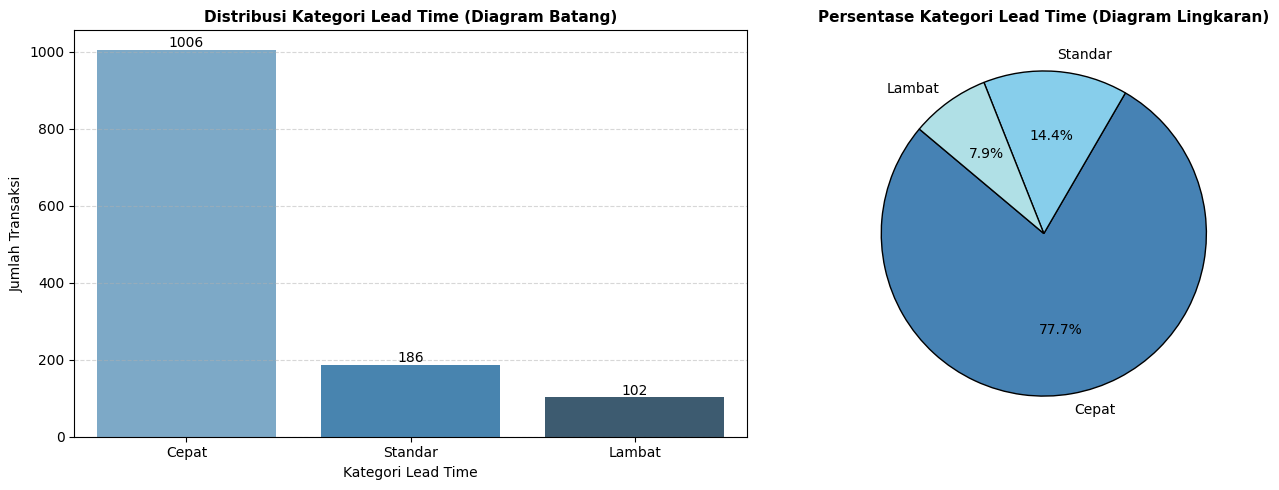

In [8]:
print("=== EKSPLORASI DATA (EDA) ===")
kategori_counts = df_clean['Kategori_LeadTime'].value_counts()

plt.figure(figsize=(14, 5))

# Subplot 1: Diagram Batang
plt.subplot(1, 2, 1)
ax = sns.barplot(x=kategori_counts.index, y=kategori_counts.values, palette='Blues_d', hue=kategori_counts.index, legend=False)
plt.title('Distribusi Kategori Lead Time (Diagram Batang)', fontsize=11, fontweight='bold')
plt.xlabel('Kategori Lead Time')
plt.ylabel('Jumlah Transaksi')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Subplot 2: Diagram Lingkaran
plt.subplot(1, 2, 2)
plt.pie(kategori_counts.values, labels=kategori_counts.index, autopct='%1.1f%%',
        colors=['#4682B4', '#87CEEB', '#B0E0E6'], startangle=140,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})
plt.title('Persentase Kategori Lead Time (Diagram Lingkaran)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

**Seleksi Atribut & Train-Test Split (80/20)**

In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Menentukan Fitur (X) dan Target (y)
features = ['Part ID', 'Description', 'WO_Month', 'WO_DayOfWeek']
X = df_clean[features].dropna().copy()
y = df_clean.loc[X.index, 'Kategori_LeadTime']

# Mengubah data teks menjadi angka agar bisa diproses model
for col in ['Part ID', 'Description']:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Pembagian data 80% Latih dan 20% Uji dengan stratifikasi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah Data Latih (Training): {len(X_train)} baris (80%)")
print(f"Jumlah Data Uji (Testing): {len(X_test)} baris (20%)")

Jumlah Data Latih (Training): 727 baris (80%)
Jumlah Data Uji (Testing): 182 baris (20%)


**Penanganan Imbalance dengan SMOTE**

In [10]:
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE

# Menerapkan SMOTE HANYA pada data latih
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Jumlah Data Training Setelah SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Jumlah Data Training Setelah SMOTE:
Kategori_LeadTime
Standar    595
Cepat      595
Lambat     595
Name: count, dtype: int64


**Pelatihan Model & Evaluasi (Overfitting & Metrics)**

=== ANALISIS OVERFITTING / UNDERFITTING ===
Akurasi Data Latih (Train Accuracy) : 96.64%
Akurasi Data Uji (Test Accuracy)     : 75.27%

=== CLASSIFICATION REPORT (PRECISION, RECALL, F1-SCORE) ===
              precision    recall  f1-score   support

       Cepat       0.89      0.83      0.86       149
      Lambat       0.17      0.14      0.15         7
     Standar       0.33      0.46      0.39        26

    accuracy                           0.75       182
   macro avg       0.46      0.48      0.47       182
weighted avg       0.78      0.75      0.76       182



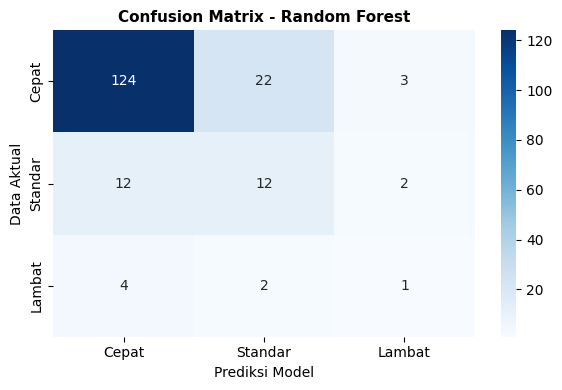

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Melatih model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)

# 2. Cek Overfitting (Akurasi Train vs Test)
train_pred = rf_model.predict(X_train_balanced)
test_pred = rf_model.predict(X_test)

acc_train = accuracy_score(y_train_balanced, train_pred)
acc_test = accuracy_score(y_test, test_pred)

print("=== ANALISIS OVERFITTING / UNDERFITTING ===")
print(f"Akurasi Data Latih (Train Accuracy) : {acc_train * 100:.2f}%")
print(f"Akurasi Data Uji (Test Accuracy)     : {acc_test * 100:.2f}%")

print("\n=== CLASSIFICATION REPORT (PRECISION, RECALL, F1-SCORE) ===")
print(classification_report(y_test, test_pred))

# 3. Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, test_pred, labels=['Cepat', 'Standar', 'Lambat'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cepat', 'Standar', 'Lambat'],
            yticklabels=['Cepat', 'Standar', 'Lambat'])
plt.title('Confusion Matrix - Random Forest', fontsize=11, fontweight='bold')
plt.xlabel('Prediksi Model')
plt.ylabel('Data Aktual')
plt.tight_layout()
plt.show()

**Penambahan Visualisasi Diagram Sesudah SMOTE**

Jumlah Data Training Setelah SMOTE:
Kategori_LeadTime
Standar    595
Cepat      595
Lambat     595
Name: count, dtype: int64


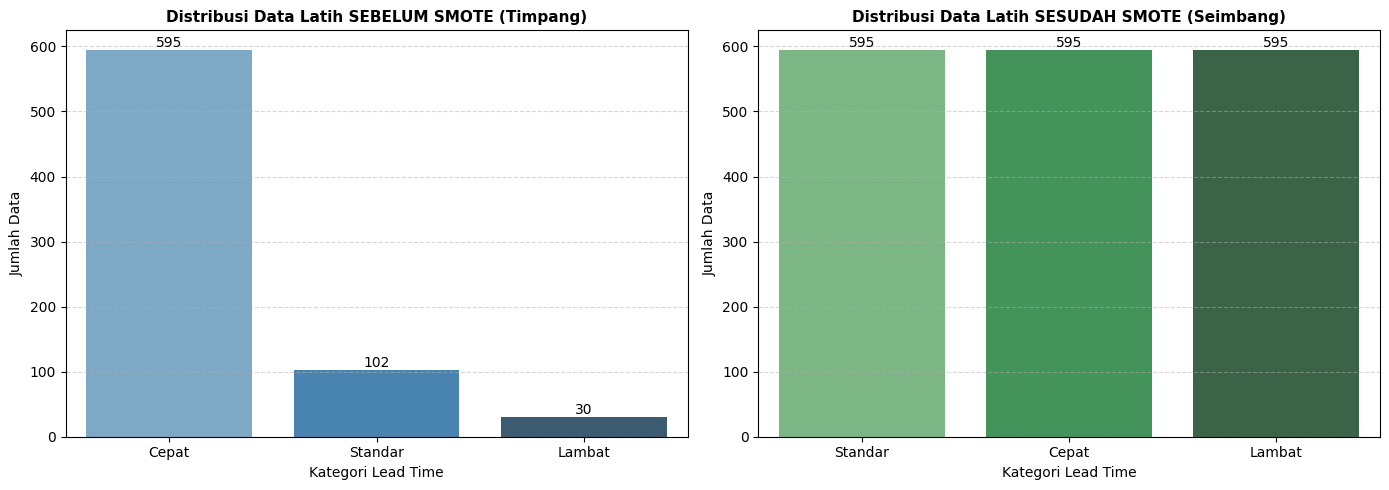

In [12]:
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Menerapkan SMOTE HANYA pada data latih
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Menghitung jumlah data setelah SMOTE
balanced_counts = pd.Series(y_train_balanced).value_counts()
print("Jumlah Data Training Setelah SMOTE:")
print(balanced_counts)

# 2. Visualisasi Perbandingan (Diagram Batang Sebelum vs Sesudah SMOTE)
plt.figure(figsize=(14, 5))

# Grafik Kiri: Sebelum SMOTE (Data Latih Asli)
plt.subplot(1, 2, 1)
original_counts = pd.Series(y_train).value_counts()
ax1 = sns.barplot(x=original_counts.index, y=original_counts.values, palette='Blues_d', hue=original_counts.index, legend=False)
plt.title('Distribusi Data Latih SEBELUM SMOTE (Timpang)', fontsize=11, fontweight='bold')
plt.xlabel('Kategori Lead Time')
plt.ylabel('Jumlah Data')
plt.grid(axis='y', linestyle='--', alpha=0.5)
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Grafik Kanan: Sesudah SMOTE (Data Latih Seimbang)
plt.subplot(1, 2, 2)
ax2 = sns.barplot(x=balanced_counts.index, y=balanced_counts.values, palette='Greens_d', hue=balanced_counts.index, legend=False)
plt.title('Distribusi Data Latih SESUDAH SMOTE (Seimbang)', fontsize=11, fontweight='bold')
plt.xlabel('Kategori Lead Time')
plt.ylabel('Jumlah Data')
plt.grid(axis='y', linestyle='--', alpha=0.5)
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()